# Treated MonoCulture Math Modelling — 20k IC50 (Julia)

Uses DifferentialEquations.jl + Optimization.jl with an ODEProblem and a Hill-type drug effect, mirroring the style of the untreated notebook.

## 1) Packages
Load or install required Julia packages for treated IC50 modelling (logistic growth with Hill drug effect).

In [5]:
# 1) Packages
using Pkg
pkgs = [
    "CSV", "DataFrames", "Statistics",
    "DifferentialEquations", "Optimization", "OptimizationOptimJL",
    "BlackBoxOptim", "Plots", "Optim"
]
for p in pkgs
    try
        Base.eval(Main, :(import $(Symbol(p))))
    catch
        Pkg.add(p)
        Base.eval(Main, :(import $(Symbol(p))))
    end
end
println("✓ Packages ready: " * join(pkgs, ", "))

✓ Packages ready: CSV, DataFrames, Statistics, DifferentialEquations, Optimization, OptimizationOptimJL, BlackBoxOptim, Plots, Optim


## 2) Imports & Paths
Bring into scope the packages, set plotting defaults, and define filesystem paths.

In [6]:
# 2) Imports & Paths
using CSV, DataFrames, Statistics
using DifferentialEquations, Optimization, OptimizationOptimJL, BlackBoxOptim
using Optim
using Plots
default(fmt=:png, legend=:topright, lw=2, size=(900,550))

# Root and directories
ROOT = raw"c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics"
UNT_PARAMS = joinpath(ROOT, "Modelling Data Notebooks", "Untreated MonoCulture", "untreated_logistic_params_20k.csv")
TREATED_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC50", "Averages")
OUT_DIR = joinpath(ROOT, "Modelling Data Notebooks", "Treated MonoCulture", "20k", "IC50")
mkpath(OUT_DIR)
println("Using treated averages dir: " * TREATED_DIR)
println("Output directory: " * OUT_DIR)

Using treated averages dir: c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC50\Averages
Output directory: c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Modelling Data Notebooks\Treated MonoCulture\20k\IC50


## 3) Utilities (Loaders)
Helpers to load treated day averages and untreated baseline r,K parameters.

In [7]:
# 3) Utilities (Loaders)
function load_day_averages(path::AbstractString)
    @assert isfile(path) "Missing CSV: $path"
    df = CSV.read(path, DataFrame)
    daycol = :Day ∈ names(df) ? :Day : Symbol(first(filter(n -> occursin("day", lowercase(String(n))), names(df))))
    valcol = Symbol("Mean Cells") ∈ names(df) ? Symbol("Mean Cells") : Symbol(first(filter(n -> occursin("mean", lowercase(String(n))) && occursin("cells", lowercase(String(n))), names(df))))
    x = Float64.(df[!, daycol]); y = Float64.(df[!, valcol])
    perm = sortperm(x); x = x[perm]; y = y[perm]
    return x, y
end

function load_untreated_rK()
    @assert isfile(UNT_PARAMS) "Missing untreated params: $UNT_PARAMS"
    df = CSV.read(UNT_PARAMS, DataFrame)
    return Dict(Symbol(r.cell_line) => (r.r, r.K) for r in eachrow(df))
end

println("Loaded utility functions")

Loaded utility functions


## 4) Model (Logistic with Hill Inhibition)
Defines Hill function, ODE, solver wrapper, and objective function.

In [8]:
# 4) Model (Logistic with Hill Inhibition)
# Hill inhibition: effect(d) = d^n / (IC50^n + d^n)
hill(dose, IC50, n) = dose^n / (IC50^n + dose^n)

function treated_logistic!(du, u, p, t)
    r, K, IC50, n, dose = p
    eff = r * (1 - hill(dose, IC50, n))
    du[1] = eff * u[1] * (1 - u[1] / K)
end

function solve_model(x::Vector{Float64}, y::Vector{Float64}, r, K; IC50=1.0, n=1.0, dose=1.0)
    u0 = [max(y[1], eps())]; tspan = (x[1], x[end])
    p = [r, K, IC50, n, dose]
    prob = ODEProblem(treated_logistic!, u0, tspan, p)
    sol = solve(prob, Rosenbrock23(); saveat=x, reltol=1e-6, abstol=1e-6)
    return sol
end

function objective(θ, x, y, r, K, dose)
    IC50, n = θ
    sol = solve_model(x, y, r, K; IC50=IC50, n=n, dose=dose)
    pred = getindex.(sol.u, 1)
    return sum(abs2, y .- pred)
end

println("Model + objective ready")

Model + objective ready


## 5) Fitting Helper
Wraps optimization of IC50 and Hill coefficient n for one treated CSV.

In [34]:
# 5) Fitting Helper
# Use Optim.jl directly (Fminbox + NelderMead) with a robust loss that penalizes solver failures.

function _safe_loss(θ, x, y, r, K, dose)
    IC50, n = θ
    # Quick parameter sanity (avoid nonsensical values early)
    if any(!isfinite, θ) || IC50 <= 0 || n <= 0
        return 1e14
    end
    try
        sol = solve_model(x, y, r, K; IC50=IC50, n=n, dose=dose)
        pred = getindex.(sol.u, 1)
        if any(!isfinite, pred)
            return 1e13
        end
        return sum(abs2, y .- pred)
    catch e
        return 1e12  # penalize failed ODE solve
    end
end

function _fit_ic50_core(x::Vector{Float64}, y::Vector{Float64}, r::Float64, K::Float64; dose=1.0, θ0=[1.0,1.0])
    lower = [1e-3, 0.1]; upper = [1e3, 5.0]
    loss(θ) = _safe_loss(θ, x, y, r, K, dose)
    res = Optim.optimize(loss, lower, upper, θ0, Optim.Fminbox(Optim.NelderMead()); maxiters=4000)
    θ̂ = Optim.minimizer(res)
    IC50̂, n̂ = θ̂
    # Re-solve once with best params (guarded)
    sol̂ = try
        solve_model(x, y, r, K; IC50=IC50̂, n=n̂, dose=dose)
    catch
        nothing
    end
    ssr = loss(θ̂)
    return (; x, y, r, K, IC50=IC50̂, n=n̂, ssr, sol=sol̂, converged=Optim.converged(res), iterations=res.iterations)
end

function fit_ic50_for_csv(csv_path::AbstractString, rK::Tuple{Float64,Float64}; dose=1.0)
    try
        x, y = load_day_averages(csv_path)
        r, K = rK
        return _fit_ic50_core(x, y, r, K; dose=dose)
    catch e
        @warn "Fit failed for $csv_path" exception=(e, catch_backtrace())
        return nothing
    end
end

function fit_ic50_xy(x::Vector{Float64}, y::Vector{Float64}, rK::Tuple{Float64,Float64}; dose=1.0)
    r, K = rK
    try
        return _fit_ic50_core(copy(x), copy(y), r, K; dose=dose)
    catch e
        @warn "In-memory fit failed" exception=(e, catch_backtrace())
        return nothing
    end
end
println("Fitting helper ready (Optim.fminbox NelderMead robust loss)")

Fitting helper ready (Optim.fminbox NelderMead robust loss)


## 7) Run Fits & Plot
Load untreated baseline r,K, perform treated fits for naive and cis lines, and plot results.

## 6) Quick Data Inspection & Plot
Load raw treated naive/cis CSVs, display first rows, and plot the time-course before fitting.

Inspecting treated day-average files:
  c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC50\Averages\A2780Naive_day_averages.csv
  c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC50\Averages\A2780cis_day_averages.csv
Naive rows: 14  Cis rows: 14


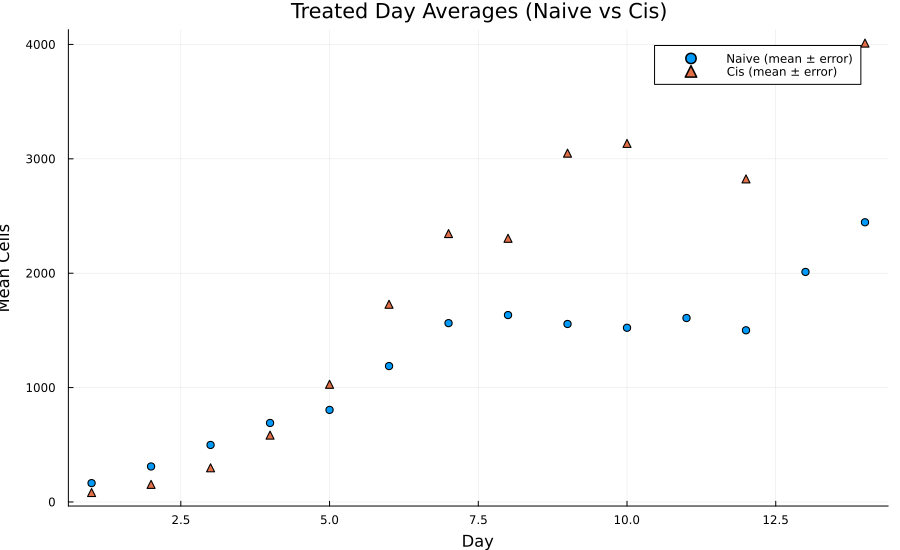

Day-average inspection complete.


In [17]:
# 6) Quick Data Inspection & Plot (Day Averages)
# Use pre-computed day-average CSVs for treated Naive and Cis lines.
AVG_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC50", "Averages")
naive_avg = joinpath(AVG_DIR, "A2780Naive_day_averages.csv")
cis_avg   = joinpath(AVG_DIR, "A2780cis_day_averages.csv")
println("Inspecting treated day-average files:\n  " * naive_avg * "\n  " * cis_avg)
@assert isfile(naive_avg) "Missing naive day averages: $(naive_avg)"
@assert isfile(cis_avg)   "Missing cis day averages: $(cis_avg)"

function load_day_avg_with_err(path::AbstractString)
    df = CSV.read(path, DataFrame)
    daycol = :Day ∈ names(df) ? :Day : first(filter(c -> occursin("day", lowercase(String(c))), names(df)))
    valcol = Symbol("Mean Cells") ∈ names(df) ? Symbol("Mean Cells") : first(filter(c -> occursin("mean", lowercase(String(c))) && occursin("cells", lowercase(String(c))), names(df)))
    errcol = Symbol("SEM Cells") ∈ names(df) ? Symbol("SEM Cells") : (Symbol("SD Cells") ∈ names(df) ? Symbol("SD Cells") : nothing)
    x = Float64.(df[!, daycol]); y = Float64.(df[!, valcol]); yerr = errcol === nothing ? nothing : Float64.(df[!, errcol])
    perm = sortperm(x); x = x[perm]; y = y[perm]; yerr = isnothing(yerr) ? nothing : yerr[perm]
    return x, y, yerr, df
end

xN, yN, yerrN, dfN = load_day_avg_with_err(naive_avg)
xC, yC, yerrC, dfC = load_day_avg_with_err(cis_avg)
println("Naive rows: ", nrow(dfN), "  Cis rows: ", nrow(dfC))

plt = scatter(xN, yN; yerror=yerrN, marker=:circle, label="Naive (mean ± error)", xlabel="Day", ylabel="Mean Cells", title="Treated Day Averages (Naive vs Cis)")
scatter!(plt, xC, yC; yerror=yerrC, marker=:utriangle, label="Cis (mean ± error)")
display(plt)
println("Day-average inspection complete.")

In [33]:
# DEBUG) Inspect data and attempt direct core fit
println("--- Debug: Inspect x/y arrays ---")
println("Naive x: ", xN)
println("Naive y: ", yN)
println("Cis   x: ", xC)
println("Cis   y: ", yC)
println("Lengths -> Naive: ", length(xN), " Cis: ", length(xC))
println("Any NaNs? Naive y: ", any(isnan, yN), " Cis y: ", any(isnan, yC))
println("Duplicate timepoints Naive: ", length(xN) - length(unique(xN)))
println("Duplicate timepoints Cis: ", length(xC) - length(unique(xC)))

if @isdefined rk
    if haskey(rk, :A2780Naive)
        rN, KN = rk[:A2780Naive]
        try
            tmp = _fit_ic50_core(xN, yN, rN, KN; dose=1.0)
            println("Direct naive core fit succeeded: IC50=$(tmp.IC50), n=$(tmp.n), SSR=$(tmp.ssr)")
        catch e
            @warn "Direct naive core fit failed" exception=(e, catch_backtrace())
        end
    end
    if haskey(rk, :A2780cis)
        rC, KC = rk[:A2780cis]
        try
            tmp2 = _fit_ic50_core(xC, yC, rC, KC; dose=1.0)
            println("Direct cis core fit succeeded: IC50=$(tmp2.IC50), n=$(tmp2.n), SSR=$(tmp2.ssr)")
        catch e
            @warn "Direct cis core fit failed" exception=(e, catch_backtrace())
        end
    end
else
    println("rk not defined yet; run Section 7 first then re-run debug.")
end

--- Debug: Inspect x/y arrays ---
Naive x: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0]
Naive y: [164.837076, 310.328588, 498.459259, 690.709722, 804.908989, 1188.288657, 1563.538156, 1634.130247, 1556.192554, 1522.992284, 1608.247685, 1500.928164, 2011.225424, 2445.406713]
Cis   x: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0]
Cis   y: [82.574769, 153.749267, 298.622724, 584.29375, 1028.857523, 1728.468171, 2346.510378, 2305.369097, 3049.632677, 3134.858873, 3720.538503, 2824.667709, 3906.991705, 4011.975926]
Lengths -> Naive: 14 Cis: 14
Any NaNs? Naive y: false Cis y: false
Duplicate timepoints Naive: 0
Duplicate timepoints Cis: 0


┌ Warning: Direct naive core fit failed
│   exception =
│    MethodError: no method matching optimize(::var"#loss#148"{Float64, Vector{Float64}, Vector{Float64}, Float64, Float64}, ::Vector{Float64}, ::Vector{Float64}, ::Vector{Float64}, ::Fminbox{NelderMead{Optim.AffineSimplexer, Optim.AdaptiveParameters}, Float64, Optim.var"#39#41"}, ::Optim.Options{Float64, Nothing}; maxiters::Int64)
│    This error has been manually thrown, explicitly, so the method may exist but be intentionally marked as unimplemented.
│    
│    Closest candidates are:
│      optimize(::Any, ::AbstractArray, ::AbstractArray, ::AbstractArray, ::Fminbox, ::Optim.Options; inplace, autodiff) got unsupported keyword argument "maxiters"
│       @ Optim C:\Users\MainFrameTower\.julia\packages\Optim\7krni\src\multivariate\solvers\constrained\fminbox.jl:376
│      optimize(::Any, ::Any, ::Any, ::AbstractArray{T}, ::Optim.AbstractOptimizer, ::Optim.Options; inplace, autodiff) where T got unsupported keyword argument "maxi

In [35]:
# 7) Run Fits & Plot (Day Averages; In-Memory Data)
# Uses xN,yN,xC,yC produced in Section 6 to avoid re-reading CSVs.
# Baseline r,K from untreated logistic params (UNT_PARAMS defined earlier).
for sym in (:xN, :yN, :xC, :yC)
    @assert isdefined(Main, sym) "Symbol $(sym) not defined — run the Section 6 data inspection cell first."
end

@assert isfile(UNT_PARAMS) "Missing untreated logistic params at: $(UNT_PARAMS)"
function load_rk_table(csv_path::AbstractString)
    df = CSV.read(csv_path, DataFrame)
    cols = Dict(lowercase(String(c)) => c for c in names(df))
    @assert all(h -> h in keys(cols), ["cell_line","r","k"]) "Untreated logistic params missing required columns"
    return Dict(Symbol(row[cols["cell_line"]]) => (Float64(row[cols["r"]]), Float64(row[cols["k"]])) for row in eachrow(df))
end
rk = load_rk_table(UNT_PARAMS)
@assert haskey(rk, :A2780Naive) && haskey(rk, :A2780cis) "Untreated r,K entries missing for A2780Naive or A2780cis"
println("Loaded untreated logistic params from: " * UNT_PARAMS)

fits = Dict{Symbol,Any}()
fits[:A2780Naive] = fit_ic50_xy(copy(xN), copy(yN), rk[:A2780Naive]; dose=1.0)
fits[:A2780cis]   = fit_ic50_xy(copy(xC), copy(yC), rk[:A2780cis]; dose=1.0)

for (k, f) in fits
    if f !== nothing
        try
            plt = scatter(f.x, f.y; label=String(k)*" data", xlabel="Day", ylabel="Mean Cells", title=String(k)*" — 20k IC50 (day averages) fit")
            plot!(plt, f.sol.t, getindex.(f.sol.u, 1); label="Model")
            display(plt)
            savefig(plt, joinpath(OUT_DIR, "$(String(k))_dayavg_fit.png"))
        catch e
            @warn "Plotting failed for $k" exception=(e, catch_backtrace())
        end
    else
        @warn "Fit object is nothing" k
    end
end

# Export combined parameter table (r,K,IC50,n,SSR)
out_csv = joinpath(OUT_DIR, "treated_ic50_20k_dayavg_fit_params.csv")
rows = DataFrame(cell_line=String[], r=Float64[], K=Float64[], IC50=Float64[], n=Float64[], SSR=Float64[])
for (name, f) in fits
    if f !== nothing
        push!(rows, (; cell_line=String(name), r=f.r, K=f.K, IC50=f.IC50, n=f.n, SSR=f.ssr))
    end
end
CSV.write(out_csv, rows)
println("Saved treated fit params → " * out_csv)
rows

┌ Warning: In-memory fit failed
│   exception =
│    MethodError: no method matching optimize(::var"#loss#158"{Float64, Vector{Float64}, Vector{Float64}, Float64, Float64}, ::Vector{Float64}, ::Vector{Float64}, ::Vector{Float64}, ::Fminbox{NelderMead{Optim.AffineSimplexer, Optim.AdaptiveParameters}, Float64, Optim.var"#39#41"}, ::Optim.Options{Float64, Nothing}; maxiters::Int64)
│    This error has been manually thrown, explicitly, so the method may exist but be intentionally marked as unimplemented.
│    
│    Closest candidates are:
│      optimize(::Any, ::AbstractArray, ::AbstractArray, ::AbstractArray, ::Fminbox, ::Optim.Options; inplace, autodiff) got unsupported keyword argument "maxiters"
│       @ Optim C:\Users\MainFrameTower\.julia\packages\Optim\7krni\src\multivariate\solvers\constrained\fminbox.jl:376
│      optimize(::Any, ::Any, ::Any, ::AbstractArray{T}, ::Optim.AbstractOptimizer, ::Optim.Options; inplace, autodiff) where T got unsupported keyword argument "maxiters"
│ 

Loaded untreated logistic params from: c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Modelling Data Notebooks\Untreated MonoCulture\untreated_logistic_params_20k.csv
Saved treated fit params → c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Modelling Data Notebooks\Treated MonoCulture\20k\IC50\treated_ic50_20k_dayavg_fit_params.csv


┌ Warning: Fit object is nothing
│   k = :A2780cis
└ @ Main In[35]:34
┌ Warning: Fit object is nothing
│   k = :A2780Naive
└ @ Main In[35]:34


Row,cell_line,r,K,IC50,n,SSR
,String,Float64,Float64,Float64,Float64,Float64


## 9) Optimization Smoke Test
Verifies Optimization + Optim integration with a simple Nelder–Mead minimization.

In [ ]:
# 8) Optimization Smoke Test
try
    println("Julia version: ", VERSION)
    println("Active project: ", Base.active_project())
    using Optimization, OptimizationOptimJL, Optim
    println("Packages loaded: Optimization, OptimizationOptimJL, Optim")
    f(x) = (x[1] - 3.0)^2
    optf = OptimizationFunction((x,p) -> f(x), Optimization.AutoForwardDiff())
    prob = Optimization.OptimizationProblem(optf, [10.0])
    res = Optimization.solve(prob, Optim.NelderMead(); maxiters=200)
    println("NelderMead test solution x*: ", res.u, ", f(x*): ", f(res.u))
catch e
    @warn "Smoke test failed" exception=e
end